# Configure Step

Run `conda run -n sitc pip install wandb`



In [ ]:
import wandb
wandb.login()                                                                           

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\CmdrC\_netrc
wandb: Currently logged in as: marilyn-smartinez (team-data-or-die) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [1]:
from pathlib import Path
import sys
import pandas as pd

# Make project src importable from this notebook location
project_root = Path.cwd().resolve().parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocessing.one_step import preprocess_one_step, OneStepOptions

# Load train data if df is not already available in memory
if "df" not in globals():
    df = pd.read_csv(project_root / "data" / "train.csv")

# Use notebook-aligned defaults from one_step.py
#----------------------------------------------------------------
# PREPROCESSING OPTIONS
#----------------------------------------------------------------

noemp_option: str = "log"
newexist_option: str = "A"
createjob_option: str = "A"
retainedjob_option: str = "A"
approvaldate_option: str = "A"
approvalfy_option: str = "A"
franchise_option: str = "binary"
urbanrural_option: str = "onehot"
revlinecr_option: str = "C"
lowdoc_option: str = "C"
disbursementgross_option: str = "A"
local_state: str = "IL"

# Accepted values:
# noemp_option: "raw" | "log" | "binning"
# newexist_option: "A" | "B"
# createjob_option: "A" | "B"
# retainedjob_option: "A" | "B"
# approvaldate_option: "A" | "B"
# approvalfy_option: "A" | "B"
# franchise_option: "binary" | "raw"
# urbanrural_option: "onehot" | "text"
# revlinecr_option: "A" | "B" | "C"
# lowdoc_option: "A" | "B" | "C"
# disbursementgross_option: "A" | "B"

options = OneStepOptions(
    noemp_option=noemp_option,
    newexist_option=newexist_option,
    createjob_option=createjob_option,
    retainedjob_option=retainedjob_option,
    approvaldate_option=approvaldate_option,
    approvalfy_option=approvalfy_option,
    franchise_option=franchise_option,
    urbanrural_option=urbanrural_option,
    revlinecr_option=revlinecr_option,
    lowdoc_option=lowdoc_option,
    disbursementgross_option=disbursementgross_option,
    local_state=local_state,
)

df_processed = preprocess_one_step(df, options=options)

print(f"Rows: {len(df_processed):,}")
print(f"Features: {df_processed.shape[1]}")
df_processed.head()





Rows: 20,768
Features: 40


,City_0,City_1,City_2,City_3,City_4,City_5,City_6,City_7,City_8,City_9,...,IsFranchise,Zone_Rural,Zone_Undefined,Zone_Urban,revlinecr_is_nonstandard,revlinecr_is_missing,has_RevLineCr,lowdoc_is_nonstandard,lowdoc_is_missing,is_LowDoc
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


In [3]:
# Validate df_processed for string/text values column-by-column
import pandas as pd

print(f"df_processed shape: {df_processed.shape}")

# 1) Columns with object/string dtype
text_dtype_cols = df_processed.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print(f"\nColumns with text-like dtype: {len(text_dtype_cols)}")
if text_dtype_cols:
    print(text_dtype_cols)
else:
    print("None")

# 2) For every column, detect rows that are actual strings
column_report = []
for col in df_processed.columns:
    s = df_processed[col]

    # True for values that are Python strings
    is_str = s.map(lambda v: isinstance(v, str))
    str_count = int(is_str.sum())

    if str_count > 0:
        samples = s[is_str].dropna().astype(str).head(5).tolist()
        column_report.append(
            {
                "column": col,
                "dtype": str(s.dtype),
                "string_rows": str_count,
                "pct_string_rows": round((str_count / len(s)) * 100, 2),
                "sample_values": samples,
            }
        )

report_df = pd.DataFrame(column_report).sort_values(
    by="string_rows", ascending=False
).reset_index(drop=True) if column_report else pd.DataFrame()

print("\nColumns containing at least one string value:")
if report_df.empty:
    print("No string values detected in df_processed.")
else:
    display(report_df)

# 3) Quick suspect list for modeling input
suspect_cols = report_df["column"].tolist() if not report_df.empty else []
print(f"\nSuspect columns to validate/encode/drop before SVM: {suspect_cols}")

df_processed shape: (20768, 40)

Columns with text-like dtype: 0
None

Columns containing at least one string value:
No string values detected in df_processed.

Suspect columns to validate/encode/drop before SVM: []


# SPLIT DATA

In [4]:
from sklearn.model_selection import StratifiedKFold, train_test_split
import numpy as np

# Split strategy for geometric model
# Train/Val Set (80%): Used for StratifiedKFold cross-validation for training/validation
# Holdout Set (20%): Reserved untouched for final reporting


# Define target and features
target_col = 'Accept'
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

print(f"Dataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}\n")

# Split
# X_trainval, y_trainval: 80% data for cross-validation
# X_holdout, y_holdout: 20% data held out for final evaluation
X_trainval, X_holdout, y_trainval, y_holdout = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train/Val set size: {X_trainval.shape[0]}")
print(f"Holdout set size: {X_holdout.shape[0]}")
print(f"Train/Val target distribution:\n{y_trainval.value_counts()}\n")
print(f"Holdout target distribution:\n{y_holdout.value_counts()}\n")

# Initialize StratifiedKFold for training/validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"StratifiedKFold splits: {skf.get_n_splits()}")
print(f"\nCross-validation fold distribution:")

# Display fold info
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"  Fold {fold_idx}: Train={len(train_idx)}, Val={len(val_idx)}")

print(f"\nHoldout set reserved for final reporting (untouched during training)")

Dataset shape: (20768, 39)
Target distribution:
Accept
1    16019
0     4749
Name: count, dtype: Int64

Train/Val set size: 16614
Holdout set size: 4154
Train/Val target distribution:
Accept
1    12815
0     3799
Name: count, dtype: Int64

Holdout target distribution:
Accept
1    3204
0     950
Name: count, dtype: Int64

StratifiedKFold splits: 5

Cross-validation fold distribution:
  Fold 1: Train=13291, Val=3323
  Fold 2: Train=13291, Val=3323
  Fold 3: Train=13291, Val=3323
  Fold 4: Train=13291, Val=3323
  Fold 5: Train=13292, Val=3322

Holdout set reserved for final reporting (untouched during training)


Linear SVM
- Geometry: maximum-margin hyperplane.
- Pros: often robust on high-dimensional engineered features.
- Cons: no native probabilities unless calibrated.

Use StandardScaler: True
ROC-AUC: 0.7232
PR-AUC: 0.8814
F1: 0.8701
Precision: 0.7723
Recall: 0.9963


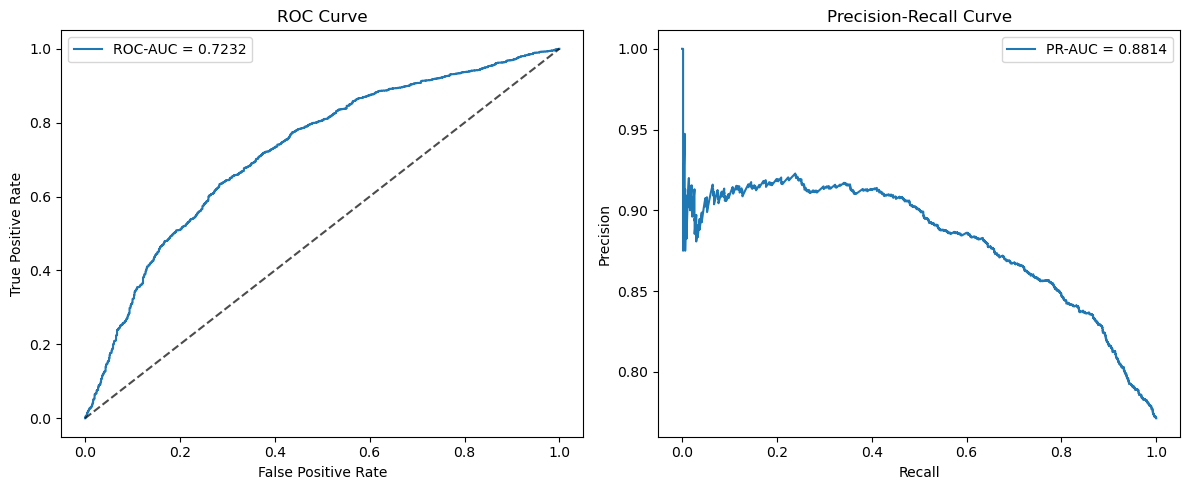

In [ ]:
# TRAINING PIPELINE - LINEAR SVM

# This cell trains a Linear SVM and evaluates it on the holdout set.

# 1) Imports: model tools, preprocessing, metrics, and plotting
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report,
    accuracy_score,
 )
import matplotlib.pyplot as plt

# 2) Toggle scaling:
#    True  -> Standardize each feature (mean=0, std=1) before training
#    False -> Skip scaling and pass raw numeric features directly
use_scaler = True

# 3) Build a pipeline so preprocessing + model happen in one object.
#    This helps keep training and inference steps consistent.
svm_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler() if use_scaler else "passthrough"),
        ("model", LinearSVC(random_state=42, max_iter=10000)),
    ]
)

# 4) Train the pipeline on the training/validation split
svm_pipeline.fit(X_trainval, y_trainval)

# 5) Predict labels and decision scores on the holdout set
#    - y_pred: final class prediction (0/1)
#    - y_score: distance from decision boundary (used for ROC/PR AUC)
y_pred = svm_pipeline.predict(X_holdout)
y_score = svm_pipeline.decision_function(X_holdout)

# 6) Compute requested evaluation metrics
metrics = {
    "ROC-AUC": roc_auc_score(y_holdout, y_score),
    "PR-AUC": average_precision_score(y_holdout, y_score),
    "F1": f1_score(y_holdout, y_pred),
    "Precision": precision_score(y_holdout, y_pred),
    "Recall": recall_score(y_holdout, y_pred),
}

# 7) Print results in a beginner-friendly way
print(f"Use StandardScaler: {use_scaler}")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

# 8) Optional visualization: ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_holdout, y_score)
precision, recall, _ = precision_recall_curve(y_holdout, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve: TPR vs FPR across thresholds
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {metrics['ROC-AUC']:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.7)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PR curve: Precision vs Recall across thresholds
axes[1].plot(recall, precision, label=f"PR-AUC = {metrics['PR-AUC']:.4f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()